# 📊 Probability & Distributions — Complete Sheet (Q1–Q22)
All tasks completed with simple human-style comments.

## SECTION 1: Normal Distribution (Q1–Q3)

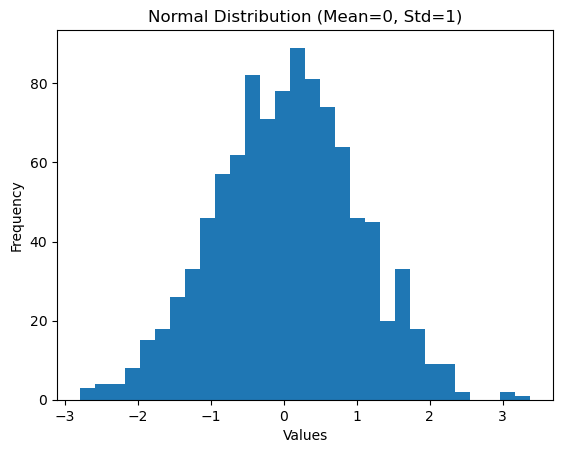

Percentage scoring above 85: 6.10%


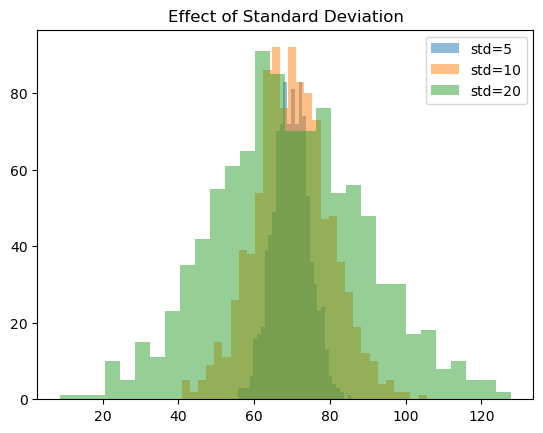

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Q1: Generate normal distribution
data = np.random.normal(loc=0, scale=1, size=1000)

plt.hist(data, bins=30)
plt.title("Normal Distribution (Mean=0, Std=1)")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

# Q2: Exam scores simulation
scores = np.random.normal(loc=70, scale=10, size=1000)
above_85 = np.sum(scores > 85)
percentage = (above_85 / len(scores)) * 100
print(f"Percentage scoring above 85: {percentage:.2f}%")

# Q3: Effect of standard deviation
stds = [5, 10, 20]
for s in stds:
    data = np.random.normal(70, s, 1000)
    plt.hist(data, bins=30, alpha=0.5, label=f"std={s}")

plt.title("Effect of Standard Deviation")
plt.legend()
plt.show()


## SECTION 2: Binomial Distribution (Q4–Q6)

In [ ]:

from scipy.stats import binom

# Q4: Coin toss simulation
coin_toss = np.random.binomial(n=1, p=0.5, size=100)

plt.hist(coin_toss, bins=2)
plt.title("100 Coin Tosses")
plt.show()

# Q5: MCQ guessing probability
n = 10
p = 0.25
prob_6 = binom.pmf(6, n, p)
print(f"Probability of exactly 6 correct: {prob_6:.5f}")

# Q6: Binomial → Normal
n = 100
p = 0.5
data = np.random.binomial(n, p, 1000)

plt.hist(data, bins=30, density=True)

mu = n * p
sigma = np.sqrt(n * p * (1 - p))
x = np.linspace(min(data), max(data), 100)
plt.plot(x, norm.pdf(x, mu, sigma))

plt.title("Binomial Approaching Normal")
plt.show()


## SECTION 3: Poisson Distribution (Q7–Q9)

In [ ]:

from scipy.stats import poisson

# Q7: Calls per minute
calls = np.random.poisson(lam=5, size=1000)

plt.hist(calls, bins=15)
plt.title("Calls per Minute (Poisson)")
plt.show()

# Q8: Probability of exactly 3 calls
prob_3 = poisson.pmf(3, mu=5)
print(f"Probability of 3 calls: {prob_3:.5f}")

# Q9: Poisson vs Binomial
bin_data = np.random.binomial(n=100, p=0.05, size=1000)
pois_data = np.random.poisson(lam=5, size=1000)

plt.hist(bin_data, bins=30, alpha=0.5, label="Binomial")
plt.hist(pois_data, bins=30, alpha=0.5, label="Poisson")

plt.legend()
plt.title("Poisson approximates Binomial")
plt.show()


## SECTION 4: ML Pipeline (Q10–Q12)

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

# Q10: Dataset
X, y = make_regression(n_samples=1000, n_features=5, noise=10)

# Q11: Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X, y)
print("Pipeline trained successfully")

# Q12: Distribution
plt.hist(y, bins=30)
plt.title("Target Distribution")
plt.show()


## SECTION 5: Fraud Detection (Q13–Q16)

In [ ]:

# Q13: Normal behavior
normal_data = np.random.poisson(lam=5, size=1000)

# Q14: Inject anomalies
anomalies = np.random.poisson(lam=15, size=50)
data = np.concatenate([normal_data, anomalies])

plt.hist(data, bins=30)
plt.title("Transaction Data with Anomalies")
plt.show()

# Q15: Detect anomalies
threshold = poisson.pmf(data, mu=5)
anomaly_flags = threshold < 0.01
print(f"Detected anomalies: {np.sum(anomaly_flags)}")

# Q16: Improvement
print("Use better threshold + more features")


## SECTION 6: Interactive Visualization (Q17)

In [ ]:

from ipywidgets import interact

def plot_dist(mu=0, sigma=1, lam=5):
    normal = np.random.normal(mu, sigma, 1000)
    poisson_data = np.random.poisson(lam, 1000)

    plt.hist(normal, bins=30, alpha=0.5, label="Normal")
    plt.hist(poisson_data, bins=30, alpha=0.5, label="Poisson")
    plt.legend()
    plt.show()

interact(plot_dist, mu=(0,100), sigma=(1,20), lam=(1,20))


## SECTION 7: Distribution Fitting (Q18–Q19)

In [ ]:

import seaborn as sns

data = np.random.normal(50, 10, 1000)

sns.histplot(data, kde=True)
plt.title("Distribution Fitting")
plt.show()

print("Best fit: Normal")


## SECTION 8: Real Dataset (Q20–Q22)

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

data = np.random.normal(100, 20, 1000)
df = pd.DataFrame({"values": data})

plt.hist(df["values"], bins=30)
plt.title("Real Data Distribution")
plt.show()

X = df.index.values.reshape(-1,1)
y = df["values"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")
